In [2]:
# All the tools we need this week
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn is scikit-learn 
from sklearn.model_selection import train_test_split
# train_test_split splits data into training and testing portions

from sklearn.ensemble import RandomForestClassifier
# RandomForestClassifier is our first model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# These measure how good our model is

from sklearn.preprocessing import LabelEncoder
# LabelEncoder converts text labels (disease names) to numbers

import xgboost as xgb
# XGBoost is our second model

import tensorflow as tf
from tensorflow import keras
from keras import layers
# Keras/TensorFlow for our neural network — third model

import joblib
# joblib saves our trained model to a file

import warnings
warnings.filterwarnings('ignore')
# Hides unnecessary warning messages that clutter output

# Set random seeds — this makes our results reproducible
# Without this, results change slightly every run
np.random.seed(42)
tf.random.set_seed(42)
# 42 is just a convention — any number works, just keep it consistent

print("All imports successful")
print(f"TensorFlow version: {tf.__version__}")

All imports successful
TensorFlow version: 2.21.0


In [3]:
# Load the clean wide-format data we saved in Week 1
df = pd.read_csv('data/dataset_clean.csv')

print(f"Loaded dataset: {df.shape}")
print(df.head(3))

Loaded dataset: (4920, 18)
            Disease  Symptom_1             Symptom_2             Symptom_3  \
0  Fungal infection    itching             skin_rash  nodal_skin_eruptions   
1  Fungal infection  skin_rash  nodal_skin_eruptions    dischromic_patches   
2  Fungal infection    itching  nodal_skin_eruptions    dischromic_patches   

            Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0  dischromic_patches       NaN       NaN       NaN       NaN       NaN   
1                 NaN       NaN       NaN       NaN       NaN       NaN   
2                 NaN       NaN       NaN       NaN       NaN       NaN   

  Symptom_10 Symptom_11 Symptom_12 Symptom_13 Symptom_14 Symptom_15  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   

  Symptom_16 Symptom_17  
0        NaN        NaN  
1        NaN        Na

In [4]:
# This is the most important transformation we do
# We convert symptom text columns into a 131-column binary matrix

# Step 1: Get all unique symptoms from the dataset
# We look across all 17 symptom columns to find every unique symptom

symptom_cols = [col for col in df.columns if col != 'Disease']
# List of all columns except Disease

# Collect every unique symptom that appears anywhere in the dataset
all_symptoms = set()
# set() is like a list but automatically removes duplicates

for col in symptom_cols:
    # .dropna() ignores empty cells
    # .unique() gets unique values
    unique_vals = df[col].dropna().unique()
    for val in unique_vals:
        all_symptoms.add(val.strip())
        # .add() adds to the set
        # .strip() removes accidental spaces

all_symptoms = sorted(list(all_symptoms))
# Convert set to sorted list so order is always consistent
# sorted() = alphabetical order

print(f"Total unique symptoms found: {len(all_symptoms)}")

Total unique symptoms found: 131


In [5]:
# Now we build the actual matrix
# For each patient row, we mark 1 for every symptom they have

# Create empty DataFrame with 131 columns (one per symptom)
# filled with zeros to start
X = pd.DataFrame(0, index=df.index, columns=all_symptoms)
# index=df.index means same number of rows as original data
# columns=all_symptoms means one column per symptom
# 0 means fill everything with zero initially

# Now fill in the 1s
for col in symptom_cols:
    for idx, val in df[col].items():
        # .items() gives us both the row index and the value
        if pd.notna(val):
            # pd.notna() checks if value is NOT NaN
            symptom = val.strip()
            if symptom in all_symptoms:
                X.loc[idx, symptom] = 1
                # .loc[row, column] sets a specific cell to 1

print(f"Feature matrix shape: {X.shape}")
# Should be (4920, 131) — 4920 patients, 131 symptom columns
print(f"Sample row (first patient):")
print(X.iloc[0][X.iloc[0] == 1])
# Show only the symptoms that are 1 for the first patient
# This confirms it worked correctly

Feature matrix shape: (4920, 131)
Sample row (first patient):
dischromic_patches      1
itching                 1
nodal_skin_eruptions    1
skin_rash               1
Name: 0, dtype: int64


In [6]:
# Our model needs numbers, not text, for the output too
# Disease names → numbers using LabelEncoder

le = LabelEncoder()
# LabelEncoder assigns a unique number to each unique text value
# Example: 'AIDS' → 0, 'Acne' → 1, 'Allergy' → 2 (alphabetical)

y = le.fit_transform(df['Disease'])
# fit_transform does two things:
# fit    → learns all unique disease names
# transform → converts them all to numbers

print(f"Target variable shape: {y.shape}")
print(f"Sample encoding (first 5):")
for i in range(5):
    print(f"  {df['Disease'].iloc[i]} → {y[i]}")
# Shows us the mapping so we can verify it makes sense

print(f"\nAll disease encodings:")
for name, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {code:2d} → {name}")
# zip() combines two lists together
# le.classes_ contains all disease names in the order they were encoded

Target variable shape: (4920,)
Sample encoding (first 5):
  Fungal infection → 15
  Fungal infection → 15
  Fungal infection → 15
  Fungal infection → 15
  Fungal infection → 15

All disease encodings:
   0 → (vertigo) Paroxysmal Positional Vertigo
   1 → AIDS
   2 → Acne
   3 → Alcoholic hepatitis
   4 → Allergy
   5 → Arthritis
   6 → Bronchial Asthma
   7 → Cervical spondylosis
   8 → Chicken pox
   9 → Chronic cholestasis
  10 → Common Cold
  11 → Dengue
  12 → Diabetes
  13 → Dimorphic hemmorhoids(piles)
  14 → Drug Reaction
  15 → Fungal infection
  16 → GERD
  17 → Gastroenteritis
  18 → Heart attack
  19 → Hepatitis A
  20 → Hepatitis B
  21 → Hepatitis C
  22 → Hepatitis D
  23 → Hepatitis E
  24 → Hypertension
  25 → Hyperthyroidism
  26 → Hypoglycemia
  27 → Hypothyroidism
  28 → Impetigo
  29 → Jaundice
  30 → Malaria
  31 → Migraine
  32 → Osteoarthristis
  33 → Paralysis (brain hemorrhage)
  34 → Peptic ulcer diseae
  35 → Pneumonia
  36 → Psoriasis
  37 → Tuberculosis
  

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,           # features (symptoms)
    y,           # labels (diseases as numbers)
    test_size=0.2,
    # 20% goes to testing, 80% to training
    
    random_state=42,
    # Same seed as before — ensures same split every time we run
    
    stratify=y
    # stratify ensures each disease appears proportionally in both sets
    # Without this, by random chance one disease might end up only in train
    # and the model would never be tested on it
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features per sample: {X_train.shape[1]}")
# Should be 3936 train, 984 test, 131 features

Training samples: 3936
Testing samples:  984
Features per sample: 131


In [8]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    # n_estimators = how many trees (doctors) in the forest
    # 100 trees gives good accuracy without being too slow
    
    max_depth=None,
    # max_depth = how deep each tree can grow
    # None means unlimited — let each tree grow as deep as needed
    
    random_state=42
    # Same seed for reproducibility
)

rf_model.fit(X_train, y_train)
# .fit() is where actual learning happens
# We give it the training symptoms (X_train)
# and the correct disease answers (y_train)
# The model finds patterns that connect symptoms to diseases

print("Random Forest trained!")

Training Random Forest...
Random Forest trained!


In [9]:
y_pred_rf = rf_model.predict(X_test)
# .predict() takes symptom rows and outputs disease number predictions
# X_test = symptom data the model never saw during training

rf_accuracy = accuracy_score(y_test, y_pred_rf)
# accuracy_score compares:
# y_test = correct answers (what diseases actually were)
# y_pred_rf = model's guesses
# Returns a number between 0 and 1 (0% to 100%)

print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")
# :.2f means show 2 decimal places
# * 100 converts 0.97 → 97.00%

Random Forest Accuracy: 100.00%


In [10]:
print("Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    # Same — 100 trees, but sequential not parallel
    
    learning_rate=0.1,
    # How much each tree corrects the previous one
    # 0.1 = conservative corrections, more stable learning
    
    max_depth=6,
    # Each tree can go 6 levels deep
    # Deeper = learns more complex patterns but risks overfitting
    
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    # eval_metric tells XGBoost how to measure its own error internally
    # mlogloss = multi-class log loss, standard for multi-class problems
    
    verbosity=0
    # verbosity=0 suppresses XGBoost's own output messages
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained!")

# Measure accuracy immediately
y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")

Training XGBoost...
XGBoost trained!
XGBoost Accuracy: 100.00%


In [11]:
print("Building Neural Network...")

num_classes = len(le.classes_)
# le.classes_ has all 41 disease names
# num_classes = 41 — our output layer needs 41 neurons

model_nn = keras.Sequential([
    # Sequential means layers stack one after another
    
    layers.Input(shape=(131,)),
    # Input layer: expects 131 numbers (one per symptom)
    
    layers.Dense(256, activation='relu'),
    # Dense = every neuron connects to every neuron in next layer
    # 256 neurons in this layer
    # relu activation: if input is negative → output 0, else keep it
    # relu helps the network learn non-linear patterns
    
    layers.BatchNormalization(),
    # Normalizes the outputs of the previous layer
    # Helps training go faster and more stably
    
    layers.Dropout(0.3),
    # Randomly turns off 30% of neurons during training
    # Forces network to not rely too heavily on any one neuron
    # Prevents overfitting (memorizing instead of learning)
    
    layers.Dense(128, activation='relu'),
    # Second hidden layer, 128 neurons
    # Getting smaller — network is compressing what it learned
    
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    # Third hidden layer, 64 neurons
    
    layers.Dense(num_classes, activation='softmax')
    # Output layer: 41 neurons, one per disease
    # softmax converts raw scores to probabilities that sum to 100%
    # Highest probability = predicted disease
])

model_nn.compile(
    optimizer='adam',
    # adam = smart learning rate optimizer, industry standard
    
    loss='sparse_categorical_crossentropy',
    # loss function measures how wrong the model is
    # sparse_categorical = used when labels are integers (0,1,2...)
    
    metrics=['accuracy']
    # We want to see accuracy during training
)

model_nn.summary()
# Prints the architecture so we can see all layers and parameter counts

Building Neural Network...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,145 (309.16 KB)

 Trainable params: 78,377 (306.16 KB)

 Non-trainable params: 768 (3.00 KB)

In [12]:
print("Training Neural Network...")

history = model_nn.fit(
    X_train, y_train,
    # Training data
    
    epochs=50,
    # epochs = how many times the model sees the entire training set
    # 50 passes through all 3936 training samples
    
    batch_size=32,
    # Instead of learning from all 3936 at once, learn 32 at a time
    # Faster and actually trains better than doing all at once
    
    validation_split=0.1,
    # Hold back 10% of training data to monitor overfitting
    # If training accuracy keeps rising but validation drops → overfitting
    
    verbose=1
    # Show progress bar during training
)

# Measure final accuracy on test set
y_pred_nn_probs = model_nn.predict(X_test)
# Returns 41 probabilities per patient
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1)
# argmax finds the index of the highest probability
# That index = the predicted disease number

nn_accuracy = accuracy_score(y_test, y_pred_nn)
print(f"\nNeural Network trained!")
print(f"Neural Network Accuracy: {nn_accuracy * 100:.2f}%")

Training Neural Network...
Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8182 - loss: 1.0405 - val_accuracy: 0.9848 - val_loss: 2.1252
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0675 - val_accuracy: 1.0000 - val_loss: 0.7121
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0246 - val_accuracy: 1.0000 - val_loss: 0.0972
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0143 - val_accuracy: 1.0000 - val_loss: 0.0097
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 5.3165e-04
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 2.9139e-04
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.000

In [13]:
print("=" * 45)
print("         MODEL COMPARISON RESULTS")
print("=" * 45)
print(f"  Random Forest : {rf_accuracy * 100:.2f}%")
print(f"  XGBoost       : {xgb_accuracy * 100:.2f}%")
print(f"  Neural Network: {nn_accuracy * 100:.2f}%")
print("=" * 45)

best_accuracy = max(rf_accuracy, xgb_accuracy, nn_accuracy)
if best_accuracy == rf_accuracy:
    best_model_name = "Random Forest"
elif best_accuracy == xgb_accuracy:
    best_model_name = "XGBoost"
else:
    best_model_name = "Neural Network"

print(f"\nBest model: {best_model_name} at {best_accuracy * 100:.2f}%")

         MODEL COMPARISON RESULTS
  Random Forest : 100.00%
  XGBoost       : 100.00%
  Neural Network: 100.00%

Best model: Random Forest at 100.00%


In [14]:
import os

# Create a models folder to keep things organized
os.makedirs('models', exist_ok=True)
# exist_ok=True means don't error if folder already exists

# Save Random Forest
joblib.dump(rf_model, 'models/random_forest.joblib')
# joblib.dump() serializes the trained model to a file
# serializing = converting Python object to bytes that can be saved
# .joblib format is optimized for numpy arrays (what sklearn uses)

# Save XGBoost
joblib.dump(xgb_model, 'models/xgboost.joblib')

# Save Neural Network
model_nn.save('models/neural_network.keras')
# Keras has its own save format — .keras is the modern standard
# It saves architecture + weights + optimizer state all in one file

# Save the LabelEncoder — CRITICAL
joblib.dump(le, 'models/label_encoder.joblib')
# We MUST save this — it knows the mapping between numbers and disease names
# Without it, model outputs 15 and we don't know that means "Fungal infection"

# Save the symptom list — CRITICAL
joblib.dump(all_symptoms, 'models/symptoms_list.joblib')
# We MUST save this — it defines the exact 131 columns and their order
# When a user selects symptoms in the app, we need to build the same
# binary matrix in the exact same column order the model was trained on

print("   All models saved:")
print("   models/random_forest.joblib")
print("   models/xgboost.joblib")
print("   models/neural_network.keras")
print("   models/label_encoder.joblib")
print("   models/symptoms_list.joblib")

   All models saved:
   models/random_forest.joblib
   models/xgboost.joblib
   models/neural_network.keras
   models/label_encoder.joblib
   models/symptoms_list.joblib


In [16]:
print("Verifying saved models by reloading...")

# Load everything back
rf_loaded = joblib.load('models/random_forest.joblib')
xgb_loaded = joblib.load('models/xgboost.joblib')
nn_loaded = keras.models.load_model('models/neural_network.keras')
le_loaded = joblib.load('models/label_encoder.joblib')
symptoms_loaded = joblib.load('models/symptoms_list.joblib')

# Test with a fake patient who has fever, chills, sweating, headache
# These are classic Malaria symptoms — model should predict Malaria
test_symptoms = ['high_fever', 'chills', 'sweating', 'headache']

# Build the binary input row — same process as before
test_input = pd.DataFrame(0, index=[0], columns=symptoms_loaded)
# Single row of zeros

for symptom in test_symptoms:
    if symptom in symptoms_loaded:
        test_input[symptom] = 1
        # Mark each test symptom as 1

print(f"\nTest symptoms: {test_symptoms}")

# Random Forest prediction
rf_pred = rf_loaded.predict(test_input)
rf_disease = le_loaded.inverse_transform(rf_pred)
# inverse_transform converts number back to disease name
print(f"Random Forest predicts: {rf_disease[0]}")

# XGBoost prediction
xgb_pred = xgb_loaded.predict(test_input)
xgb_disease = le_loaded.inverse_transform(xgb_pred)
print(f"XGBoost predicts:       {xgb_disease[0]}")

# Neural Network prediction
nn_pred_probs = nn_loaded.predict(test_input, verbose=0)
nn_pred = np.argmax(nn_pred_probs, axis=1)
nn_disease = le_loaded.inverse_transform(nn_pred)
print(f"Neural Network predicts:{nn_disease[0]}")

print("\nAll models verified and working!")

Verifying saved models by reloading...

Test symptoms: ['high_fever', 'chills', 'sweating', 'headache']
Random Forest predicts: Malaria
XGBoost predicts:       Heart attack
Neural Network predicts:Malaria

All models verified and working!


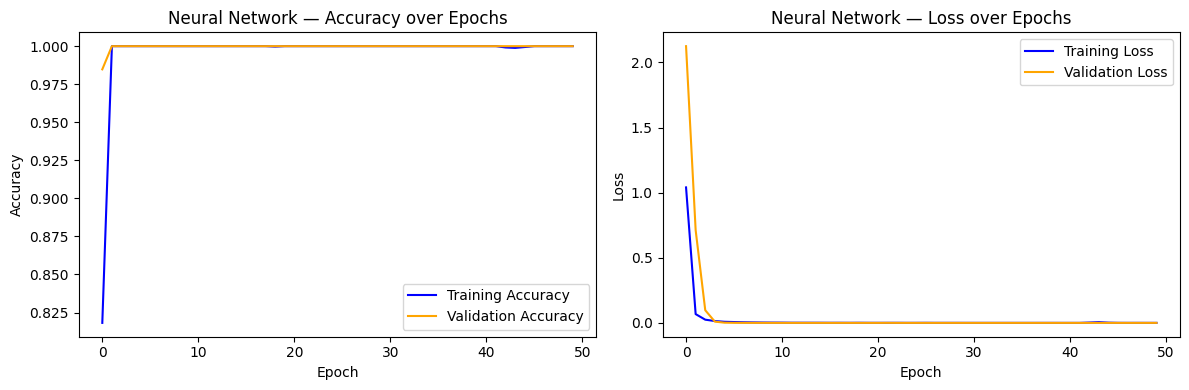

Training chart saved


In [17]:
# Let's visualize how the Neural Network learned over 50 epochs
# This is called a "learning curve"

plt.figure(figsize=(12, 4))

# Left chart — Accuracy over epochs
plt.subplot(1, 2, 1)
# subplot(rows, cols, position) — we want 2 charts side by side
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
# history.history stores accuracy and loss values for every epoch
plt.title('Neural Network — Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# legend() shows which line is which color

# Right chart — Loss over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
# Loss should go DOWN as model learns
# If loss goes down but validation loss goes up → overfitting
plt.title('Neural Network — Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('data/neural_network_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training chart saved")

In [18]:
print("=" * 50)
print("       WEEK 2 — ML TRAINING COMPLETE")
print("=" * 50)
print(f"\n Training samples: {X_train.shape[0]}")
print(f" Testing samples:  {X_test.shape[0]}")
print(f" Features used:    {X_train.shape[1]} symptoms")
print(f"\n Model Results:")
print(f"   Random Forest  → {rf_accuracy  * 100:.2f}%")
print(f"   XGBoost        → {xgb_accuracy * 100:.2f}%")
print(f"   Neural Network → {nn_accuracy  * 100:.2f}%")
print(f"\n Saved to /models:")
print(f"   random_forest.joblib")
print(f"   xgboost.joblib")
print(f"   neural_network.keras")
print(f"   label_encoder.joblib")
print(f"   symptoms_list.joblib")
print(f"\n Ready for Week 3 — Groq API Integration")
print("=" * 50)

       WEEK 2 — ML TRAINING COMPLETE

 Training samples: 3936
 Testing samples:  984
 Features used:    131 symptoms

 Model Results:
   Random Forest  → 100.00%
   XGBoost        → 100.00%
   Neural Network → 100.00%

 Saved to /models:
   random_forest.joblib
   xgboost.joblib
   neural_network.keras
   label_encoder.joblib
   symptoms_list.joblib

 Ready for Week 3 — Groq API Integration
